Nama: Muhamad Kemal Faza

NIM: 24060124120013

Kelas: E

Mata Kuliah: Grafik dan Teknik Interaktif

# Operator Roberts — Deteksi Tepi

Operator Roberts (sering disebut **operator silang** / *cross operator*) adalah
salah satu operator gradien pertama yang menggunakan kernel **2×2** untuk
mendeteksi tepi. Berbeda dengan Sobel dan Prewitt (3×3), Roberts menghitung
turunan arah **diagonal** (↘ dan ↙), bukan horizontal/vertikal langsung.

Konsep: Gradien dihitung dari selisih piksel diagonal, sehingga tepi terdeteksi
dalam dua arah silang.

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["image.cmap"] = "gray"

THRESHOLD = 50

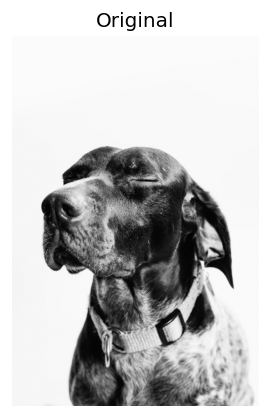

In [6]:
img = cv2.imread("dog.jpg", 0)

plt.figure(figsize=(6, 4))
plt.imshow(img)
plt.title("Original")
plt.axis("off")
plt.show()

## Kernel & Rumus

### Gx — arah diagonal ↘
$$G_x = f(i+1, j+1) - f(i, j)$$

$$
\begin{bmatrix}
+1 & 0 \\
0 & -1
\end{bmatrix}
$$

### Gy — arah diagonal ↙
$$G_y = f(i, j+1) - f(i+1, j)$$

$$
\begin{bmatrix}
0 & +1 \\
-1 & 0
\end{bmatrix}
$$

### Magnitude
$$K[f(x,y)] = |G_x| + |G_y|$$

In [ ]:
def convolve2d(image, kernel):
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    h, w = image.shape
    padded = np.pad(image, ((ph, ph), (pw, pw)), mode="edge")
    result = np.zeros_like(image, dtype=np.float64)
    for y in range(h):
        for x in range(w):
            result[y, x] = np.sum(padded[y : y + kh, x : x + kw] * kernel)
    return result


def detect_edges(image, kernel_x, kernel_y, threshold=30):
    dx = convolve2d(image, kernel_x)
    dy = convolve2d(image, kernel_y)
    magnitude = np.abs(dx) + np.abs(dy)
    magnitude = np.clip(magnitude, 0, 255).astype(np.uint8)
    binary = (magnitude > threshold).astype(np.uint8) * 255
    return magnitude, binary


def show_result(name, original, kernel_x, kernel_y, threshold=30):
    mag, binary = detect_edges(original, kernel_x, kernel_y, threshold)
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].imshow(mag)
    axes[0].set_title(f"{name} : Magnitude")
    axes[0].axis("off")
    axes[1].imshow(binary)
    axes[1].set_title(f"{name} : Threshold > {threshold}")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

## Algoritma Deteksi Tepi Roberts

1. Input citra grayscale $f(x,y)$ dan parameter ambang $T$
2. Konvolusi citra dengan kernel $G_x \rightarrow D_x$
3. Konvolusi citra dengan kernel $G_y \rightarrow D_y$
4. Hitung kekuatan tepi: $K[f(x,y)] = |D_x| + |D_y|$
5. Thresholding: piksel dengan $K > T$ menjadi tepi (putih), sisanya latar (hitam)

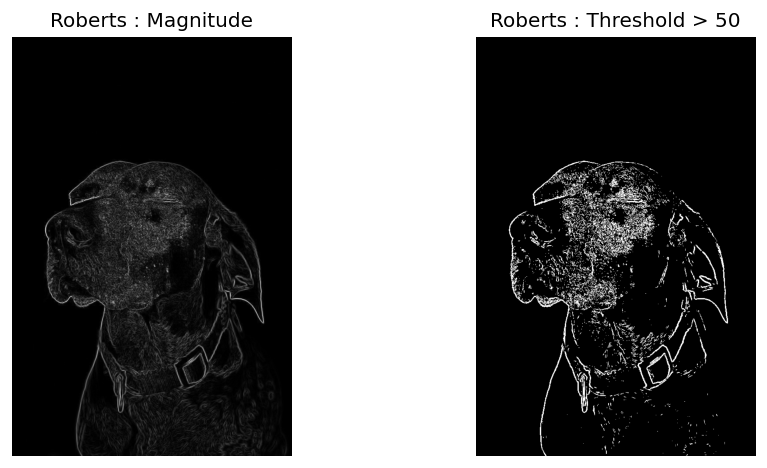

In [8]:
kernel_roberts_x = np.array([[1, 0],
                              [0, -1]], dtype=np.float64)
kernel_roberts_y = np.array([[0, 1], 
                              [-1, 0]], dtype=np.float64)

show_result(
    "Roberts", img, kernel_roberts_x, kernel_roberts_y, threshold=THRESHOLD
)

## Kesimpulan
Kernel 2×2 membuat Roberts sensitif terhadap noise (tidak ada smoothing/averaging). Tepi yang dihasilkan juga tipis dan tajam, yang mana cocok untuk citra kontras tinggi. Lalu posisi tepi sedikit bergeser kurang lebih 0.5 piksel karena kernel berpusat di antara piksel, bukan pada piksel itu sendiri. Operator Roberts ini lebih unggul daripada Operator Sobel atau Prewitt dalam mendeteksi tepi diagonal.